# System 2107: Irradiance Audit and QC
- Inputs: irradiance CSV and supporting system metadata only. The audit leaves raw data unchanged; approved flag-only processing follows below. No alignment or timestamp changes.
- Full-file statistics; selected windows are labeled examples. The narrow 14 MB, two-column file fits in memory.
- Run from the repository root or `notebooks/` with pandas/NumPy. SVG plots need no plotting package.
- Missingness uses pandas' default CSV NA tokens. Parsing/conversion creates diagnostic series; raw strings stay unchanged.

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from collections import Counter
import csv, json, hashlib, html, platform
import numpy as np
import pandas as pd
try:
    from IPython.display import display, SVG
except ImportError:
    def display(obj):
        print(obj.to_string() if isinstance(obj, (pd.DataFrame, pd.Series)) else obj)
    def SVG(data):
        return data
ROOT = Path.cwd()
if not (ROOT / 'data/2107/raw/2107_irradiance_data.csv').is_file():
    ROOT = ROOT.parent
CSV = ROOT / 'data/2107/raw/2107_irradiance_data.csv'
META = ROOT / 'data/2107/raw/2107_system_metadata.json'
assert CSV.is_file() and META.is_file(), 'Run from repository root or notebooks/'
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            digest.update(block)
    return digest.hexdigest()
input_hashes = {str(p.relative_to(ROOT)):sha256(p) for p in (CSV,META)}
metadata = json.loads(META.read_text(encoding='utf-8'))
print('Input:', CSV.relative_to(ROOT), 'bytes:',CSV.stat().st_size)
print('Python:',platform.python_version(),'pandas:',pd.__version__,'NumPy:',np.__version__)

Input: data\2107\raw\2107_irradiance_data.csv bytes: 13990782
Python: 3.11.9 pandas: 3.0.6 NumPy: 2.4.6


## 1. Schema and metadata
Check CSV record widths and header duplicates before pandas can rename duplicate columns. Report full-file inferred dtypes separately from the string-preserving audit frame. Metadata units are supporting evidence; the CSV has no unit field.

In [2]:
with CSV.open(newline='', encoding='utf-8-sig') as f:
    reader = csv.reader(f)
    header = next(reader)
    record_count, bad_widths = 0, []
    for row in reader:
        record_count += 1
        if len(row) != len(header):
            bad_widths.append((record_count,len(row)))
print('Columns:',header,'count:',len(header),'records:',record_count)
print('Duplicate headers:',{k:v for k,v in Counter(header).items() if v>1},'wrong-width rows:',bad_widths[:10])
assert not bad_widths and len(header)==len(set(header)), 'Review structural anomalies first'
TIMESTAMP = 'measured_on'
assert TIMESTAMP in header
CHANNELS = [c for c in header if c != TIMESTAMP]
frame = pd.read_csv(CSV, dtype={c:'str' for c in CHANNELS}, converters={TIMESTAMP:str})
assert len(frame)==record_count
inferred = {c:set() for c in header}
for chunk in pd.read_csv(CSV, chunksize=50000):
    for c in header:
        inferred[c].add(str(chunk[c].dtype))
del chunk
schema = pd.DataFrame({'column':header,'inferred_dtypes':[', '.join(sorted(inferred[c])) for c in header]})
display(schema)
print('Timestamp:',TIMESTAMP,'measurement channels:',len(CHANNELS))
print('Exact duplicate parsed-field rows beyond first:',int(frame.duplicated().sum()))
print('First five records (example only):')
display(frame.head())
meta_rows=[]
for c in CHANNELS:
    metric=metadata['Metrics'].get(c,{})
    suffix=c.rsplit('_',1)[-1]
    meta_rows.append(dict(column=c,metadata_present=bool(metric),sensor_name=metric.get('sensor_name'),
        common_name=metric.get('common_name'),metric_id=metric.get('metric_id'),
        metric_id_matches=str(metric.get('metric_id'))==suffix,
        units=metric.get('units'),raw_units=metric.get('raw_units'),
        units_match_expected=metric.get('units')=='W/m^2',source_id=metric.get('source_id'),
        aggregation=metric.get('aggregation_type'),scale=metric.get('calc_scale'),offset=metric.get('calc_offset')))
metric_check=pd.DataFrame(meta_rows)
display(metric_check)
meta_irradiance={k for k,v in metadata['Metrics'].items() if 'irradiance' in (k+' '+v.get('common_name','')).lower()}
print('Metadata irradiance channels absent from CSV:',sorted(meta_irradiance-set(CHANNELS)))
print('CSV channels absent from metadata:',sorted(set(CHANNELS)-set(metadata['Metrics'])))
print('Metadata mismatches:')
display(metric_check.loc[~metric_check.metadata_present | ~metric_check.metric_id_matches | ~metric_check.units_match_expected])
print('Timezone:',metadata['System'].get('timezone_code'),metadata['System'].get('comments'))
print('System-level metadata bounds:',metadata['System'].get('first_timestamp'),metadata['System'].get('last_timestamp'))

Columns: ['measured_on', 'poa_irradiance_o_149574'] count: 2 records: 531019
Duplicate headers: {} wrong-width rows: []
Timestamp: measured_on measurement channels: 1
Exact duplicate parsed-field rows beyond first: 0
First five records (example only):
Metadata irradiance channels absent from CSV: []
CSV channels absent from metadata: []
Metadata mismatches:
Timezone: PST8PDT Actual timezone is US/Pacific but needed to use special PST8PDT. System is a participant in the DOE Solar Data Prize 2023
System-level metadata bounds: 2018-12-15 00:15:00 2023-11-15 12:21:50


,column,inferred_dtypes
0,measured_on,str
1,poa_irradiance_o_149574,float64


,measured_on,poa_irradiance_o_149574
0,2017-11-01 07:10:00,0.0
1,2017-11-01 07:15:00,0.0
2,2017-11-01 07:20:00,0.0
3,2017-11-01 07:25:00,0.0
4,2017-11-01 09:00:00,267.5


,column,metadata_present,sensor_name,common_name,metric_id,metric_id_matches,units,raw_units,units_match_expected,source_id,aggregation,scale,offset
0,poa_irradiance_o_149574,True,poa_irradiance (W/m^2),Irradiance POA,149574,True,W/m^2,W/m^2,True,None,avg,1.0,0.0


,column,metadata_present,sensor_name,common_name,metric_id,metric_id_matches,units,raw_units,units_match_expected,source_id,aggregation,scale,offset


## 2. Raw timestamps and cadence
Intervals follow file order. The full interval-frequency table includes every observed length. The electrical audit found a five-minute Pacific wall-clock pattern, six spring skips, and no repeated fall hour; this comparison uses those reviewed findings, not another CSV.

In [3]:
raw_time=frame[TIMESTAMP]
parsed=pd.to_datetime(raw_time,format='%Y-%m-%d %H:%M:%S',errors='coerce')
seconds=parsed.diff().dt.total_seconds()
interval_counts=seconds.value_counts().sort_index().rename('count').to_frame()
interval_counts['pct_intervals']=100*interval_counts['count']/seconds.notna().sum()
print('First/last raw:',raw_time.iloc[0],raw_time.iloc[-1])
print('Parsed min/max:',parsed.min(),parsed.max(),'parse failures:',int(parsed.isna().sum()))
display(frame.loc[parsed.isna(),[TIMESTAMP]])
print('Nondecreasing:',parsed.is_monotonic_increasing,'strictly increasing:',bool((seconds.iloc[1:]>0).all()))
print('Raw timestamp duplicates beyond first:',int(raw_time.duplicated().sum()),
      'parsed timestamp duplicates beyond first:',int(parsed.dropna().duplicated().sum()))
display(frame.loc[raw_time.duplicated(keep=False)].head(20))
print('All interval lengths (seconds):')
display(interval_counts)
print('Modal positive interval:',float(seconds[seconds>0].mode().iloc[0]),'seconds')
print('Zero/negative intervals:',int(seconds.eq(0).sum()),int(seconds.lt(0).sum()),
      'off-five-minute interval lengths:',int((seconds.dropna()%300!=0).sum()))
print('Metadata first/last equal CSV:',metadata['System'].get('first_timestamp')==raw_time.iloc[0],
      metadata['System'].get('last_timestamp')==raw_time.iloc[-1])

First/last raw: 2017-11-01 07:10:00 2023-11-01 23:55:00
Parsed min/max: 2017-11-01 07:10:00 2023-11-01 23:55:00 parse failures: 0
Nondecreasing: True strictly increasing: True
Raw timestamp duplicates beyond first: 0 parsed timestamp duplicates beyond first: 0
All interval lengths (seconds):
Modal positive interval: 300.0 seconds
Zero/negative intervals: 0 0 off-five-minute interval lengths: 0
Metadata first/last equal CSV: False False


,measured_on


,measured_on,poa_irradiance_o_149574


,count,pct_intervals
measured_on,,
300.0,494105,93.048635
600.0,15521,2.922876
900.0,13293,2.503305
1200.0,7898,1.487332
1500.0,52,0.009793
1800.0,29,0.005461
2100.0,11,0.002071
2400.0,2,0.000377
2700.0,1,0.000188


## 3. DST, gaps, and coverage
- Benchmark: five-minute naive wall-clock slots from the first to last record, inclusive. A diagnostic index counts slots; no rows are added to the dataset.
- Exclude Pacific spring 02:00-02:55 slots for a conditional local-wall-clock benchmark. Fall ambiguity remains unresolved; this is not UTC/elapsed-time completeness.
- Gap endpoints are bounding observed timestamps; duration is their separation. Expected absent slots = separation/300 - 1 on the grid.
- Short/long means separation <=1 hour / >1 hour, excluding DST-overlap gaps. Cause is unresolved; frequent longer night intervals may reflect reporting cadence, not accidental loss.
- Full `gap_table` remains available in memory. Display longest gaps, short examples, and all DST-overlap gaps.

In [4]:
assert parsed.notna().all() and parsed.is_monotonic_increasing and not parsed.duplicated().any(), 'Coverage needs unique ordered parsed timestamps'
assert (seconds.dropna()%300==0).all(), 'Review off-grid intervals before five-minute coverage'
def sunday(year,month,ordinal):
    start=datetime(year,month,1)
    return start+timedelta(days=(6-start.weekday())%7+7*(ordinal-1))
assert parsed.min().year>=2007
spring_slots=[]
dst_records=[]
for year in range(parsed.min().year,parsed.max().year+1):
    for season,date in [('spring',sunday(year,3,2)),('fall',sunday(year,11,1))]:
        if not parsed.min().normalize()<=date<=parsed.max().normalize():
            continue
        day=(parsed>=date)&(parsed<date+timedelta(days=1))
        hour=2 if season=='spring' else 1
        critical=day & parsed.dt.hour.eq(hour)
        near=(parsed>=date)&(parsed<date+timedelta(hours=4))
        irregular=near & seconds.ne(300) & seconds.notna()
        dst_records.append(dict(year=year,season=season,date=str(date.date()),rows=int(day.sum()),
            critical_hour_rows=int(critical.sum()),duplicate_critical_strings=int(raw_time[critical].duplicated().sum()),
            irregular_nearby=[dict(previous=raw_time.iloc[i-1],current=raw_time.iloc[i],seconds=float(seconds.iloc[i])) for i in np.flatnonzero(irregular)]))
        if season=='spring':
            spring_slots.extend(pd.date_range(date+timedelta(hours=2),periods=12,freq='5min'))
dst_audit=pd.DataFrame(dst_records)
display(dst_audit)
gap_table=pd.DataFrame({'gap_start':raw_time.shift(),'gap_end':raw_time,'seconds':seconds}).loc[seconds>300].copy()
gap_table['gap_duration']=pd.to_timedelta(gap_table.seconds,unit='s')
gap_table['expected_5min_missing']=(gap_table.seconds/300-1).astype(int)
gap_table['dst_spring_slots']=0
observed_index=pd.DatetimeIndex(parsed)
missing_spring=pd.DatetimeIndex(spring_slots).difference(observed_index).tolist()
positions=np.searchsorted(parsed.to_numpy(),pd.DatetimeIndex(missing_spring).to_numpy())
for position,count in Counter(positions).items():
    gap_table.loc[position,'dst_spring_slots']=count
gap_table['non_dst_missing_slots']=gap_table.expected_5min_missing-gap_table.dst_spring_slots
gap_table['category']=np.where(gap_table.dst_spring_slots>0,
    np.where(gap_table.non_dst_missing_slots==0,'DST only','DST plus other missing slots'),
    np.where(gap_table.seconds<=3600,'short non-DST','long non-DST'))
print('Gap counts and candidate slots by category:')
gap_summary=gap_table.groupby('category').agg(periods=('seconds','size'),candidate_slots=('expected_5min_missing','sum'),
    dst_slots=('dst_spring_slots','sum'),non_dst_slots=('non_dst_missing_slots','sum'))
display(gap_summary)
print('Longest bounding intervals:')
display(gap_table.sort_values('seconds',ascending=False).head(15))
print('Short gap examples (not a complete listing):')
display(gap_table.loc[gap_table.category=='short non-DST'].head(10))
print('Every DST-overlap gap:')
display(gap_table.loc[gap_table.dst_spring_slots>0])
reference=pd.date_range(parsed.iloc[0],parsed.iloc[-1],freq='5min')
assert pd.DatetimeIndex(parsed).isin(reference).all()
conditional_reference=reference[~reference.isin(pd.DatetimeIndex(spring_slots))]
coverage=dict(duration=str(parsed.iloc[-1]-parsed.iloc[0]),rows=len(frame),naive_5min_slots=len(reference),
    spring_slots_excluded=len(reference)-len(conditional_reference),conditional_expected_slots=len(conditional_reference),
    naive_absent_slots=len(reference)-len(frame),non_dst_absent_slots=len(conditional_reference)-len(frame),
    naive_present_pct=100*len(frame)/len(reference),conditional_present_pct=100*len(frame)/len(conditional_reference))
assert gap_table.expected_5min_missing.sum()==coverage['naive_absent_slots']
assert gap_table.non_dst_missing_slots.sum()==coverage['non_dst_absent_slots']
display(pd.Series(coverage,name='coverage'))
expected_year=pd.Series(conditional_reference.year).value_counts().sort_index()
actual_year=parsed.dt.year.value_counts().sort_index()
yearly=pd.DataFrame({'conditional_expected_slots':expected_year,'rows':actual_year})
yearly['present_pct']=100*yearly.rows/yearly.conditional_expected_slots
display(yearly)
print('Interval counts by ending wall-clock hour:')
display(pd.crosstab(parsed.dt.hour,seconds).reindex(columns=[300.,600.,900.,1200.],fill_value=0))

Gap counts and candidate slots by category:
Longest bounding intervals:
Short gap examples (not a complete listing):
Every DST-overlap gap:
Interval counts by ending wall-clock hour:


,year,season,date,rows,critical_hour_rows,duplicate_critical_strings,irregular_nearby
0,2017,fall,2017-11-05,76,5,0,"[{'previous': '2017-11-04 14:35:00', 'current': '2017-11-05 01:10:00', 'seconds': 38100.0}, {'previous': '2017-11-05 01:10:00', 'current': '2017-11-05 01:20:00', 'seconds': 600.0}, {'previous': '2017-11-05 01:35:00', 'current': '2017-11-05 02:20:00', 'seconds': 2700.0}, {'previous': '2017-11-05 02:20:00', 'current': '2017-11-05 02:30:00', 'seconds': 600.0}, {'previous': '2017-11-05 02:30:00', 'current': '2017-11-05 03:40:00', 'seconds': 4200.0}, {'previous': '2017-11-05 03:40:00', 'current': '2017-11-05 03:50:00', 'seconds': 600.0}]"
1,2018,spring,2018-03-11,275,0,0,"[{'previous': '2018-03-11 01:55:00', 'current': '2018-03-11 03:00:00', 'seconds': 3900.0}]"
2,2018,fall,2018-11-04,288,12,0,[]
3,2019,spring,2019-03-10,276,0,0,"[{'previous': '2019-03-10 01:55:00', 'current': '2019-03-10 03:00:00', 'seconds': 3900.0}]"
4,2019,fall,2019-11-03,288,12,0,[]
5,2020,spring,2020-03-08,229,0,0,"[{'previous': '2020-03-07 23:40:00', 'current': '2020-03-08 00:00:00', 'seconds': 1200.0}, {'previous': '2020-03-08 00:10:00', 'current': '2020-03-08 00:20:00', 'seconds': 600.0}, {'previous': '2020-03-08 00:20:00', 'current': '2020-03-08 00:35:00', 'seconds': 900.0}, {'previous': '2020-03-08 01:05:00', 'current': '2020-03-08 01:15:00', 'seconds': 600.0}, {'previous': '2020-03-08 01:25:00', 'current': '2020-03-08 01:40:00', 'seconds': 900.0}, {'previous': '2020-03-08 01:40:00', 'current': '2020-03-08 01:55:00', 'seconds': 900.0}, {'previous': '2020-03-08 01:55:00', 'current': '2020-03-08 03:05:00', 'seconds': 4200.0}, {'previous': '2020-03-08 03:10:00', 'current': '2020-03-08 03:20:00', 'seconds': 600.0}, {'previous': '2020-03-08 03:25:00', 'current': '2020-03-08 03:35:00', 'seconds': 600.0}]"
6,2020,fall,2020-11-01,240,12,0,"[{'previous': '2020-11-01 00:50:00', 'current': '2020-11-01 01:00:00', 'seconds': 600.0}, {'previous': '2020-11-01 02:05:00', 'current': '2020-11-01 02:25:00', 'seconds': 1200.0}, {'previous': '2020-11-01 02:30:00', 'current': '2020-11-01 02:45:00', 'seconds': 900.0}, {'previous': '2020-11-01 02:50:00', 'current': '2020-11-01 03:00:00', 'seconds': 600.0}, {'previous': '2020-11-01 03:25:00', 'current': '2020-11-01 03:35:00', 'seconds': 600.0}]"
7,2021,spring,2021-03-14,233,0,0,"[{'previous': '2021-03-13 23:40:00', 'current': '2021-03-14 00:00:00', 'seconds': 1200.0}, {'previous': '2021-03-14 00:00:00', 'current': '2021-03-14 00:20:00', 'seconds': 1200.0}, {'previous': '2021-03-14 00:25:00', 'current': '2021-03-14 00:40:00', 'seconds': 900.0}, {'previous': '2021-03-14 00:40:00', 'current': '2021-03-14 00:55:00', 'seconds': 900.0}, {'previous': '2021-03-14 01:15:00', 'current': '2021-03-14 01:30:00', 'seconds': 900.0}, {'previous': '2021-03-14 01:30:00', 'current': '2021-03-14 01:50:00', 'seconds': 1200.0}, {'previous': '2021-03-14 01:55:00', 'current': '2021-03-14 03:05:00', 'seconds': 4200.0}, {'previous': '2021-03-14 03:05:00', 'current': '2021-03-14 03:15:00', 'seconds': 600.0}, {'previous': '2021-03-14 03:30:00', 'current': '2021-03-14 03:45:00', 'seconds': 900.0}]"
8,2021,fall,2021-11-07,236,9,0,"[{'previous': '2021-11-06 23:50:00', 'current': '2021-11-07 00:05:00', 'seconds': 900.0}, {'previous': '2021-11-07 00:10:00', 'current': '2021-11-07 00:25:00', 'seconds': 900.0}, {'previous': '2021-11-07 00:40:00', 'current': '2021-11-07 00:50:00', 'seconds': 600.0}, {'previous': '2021-11-07 01:10:00', 'current': '2021-11-07 01:25:00', 'seconds': 900.0}, {'previous': '2021-11-07 01:35:00', 'current': '2021-11-07 01:45:00', 'seconds': 600.0}, {'previous': '2021-11-07 02:00:00', 'current': '2021-11-07 02:10:00', 'seconds': 600.0}, {'previous': '2021-11-07 02:10:00', 'current': '2021-11-07 02:20:00', 'seconds': 600.0}, {'previous': '2021-11-07 02:35:00', 'current': '2021-11-07 02:55:00', 'seconds': 1200.0}, {'previous': '2021-11-07 03:10:00', 'current': '2021-11-07 03:20:00', 'seconds': 600.0}]"
9,2022,spring,2022-03-13

,periods,candidate_slots,dst_slots,non_dst_slots
category,,,,
DST only,3,36,36,0
DST plus other missing slots,3,40,36,4
long non-DST,98,33854,0,33854
short non-DST,36809,66261,0,66261


,gap_start,gap_end,seconds,gap_duration,expected_5min_missing,dst_spring_slots,non_dst_missing_slots,category
388965,2022-02-18 13:20:00,2022-03-07 11:25:00,1461900.0,16 days 22:05:00,4872,0,4872,long non-DST
2588,2018-01-08 12:10:00,2018-01-22 12:55:00,1212300.0,14 days 00:45:00,4040,0,4040,long non-DST
2575,2017-12-29 11:20:00,2018-01-08 11:05:00,863100.0,9 days 23:45:00,2876,0,2876,long non-DST
24757,2018-04-13 11:30:00,2018-04-23 09:40:00,857400.0,9 days 22:10:00,2857,0,2857,long non-DST
411480,2022-06-08 00:00:00,2022-06-17 10:10:00,814200.0,9 days 10:10:00,2713,0,2713,long non-DST
442582,2022-10-23 07:10:00,2022-10-26 07:15:00,259500.0,3 days 00:05:00,864,0,864,long non-DST
364620,2021-11-04 07:05:00,2021-11-05 07:15:00,87000.0,1 days 00:10:00,289,0,289,long non-DST
647,2017-11-19 06:40:00,2017-11-20 06:40:00,86400.0,1 days 00:00:00,287,0,287,long non-DST
482,2017-11-07 06:30:00,2017-11-08 06:25:00,86100.0,0 days 23:55:00,286,0,286,long non-DST
612,2017-11-11 06:30:00,2017-11-12 06:25:00,86100.0,0 days 23:55:00,286,0,286,long non-DST


,gap_start,gap_end,seconds,gap_duration,expected_5min_missing,dst_spring_slots,non_dst_missing_slots,category
6,2017-11-01 22:05:00,2017-11-01 22:30:00,1500.0,0 days 00:25:00,4,0,4,short non-DST
129,2017-11-02 08:40:00,2017-11-02 08:55:00,900.0,0 days 00:15:00,2,0,2,short non-DST
131,2017-11-02 09:00:00,2017-11-02 09:10:00,600.0,0 days 00:10:00,1,0,1,short non-DST
133,2017-11-02 09:15:00,2017-11-02 09:25:00,600.0,0 days 00:10:00,1,0,1,short non-DST
134,2017-11-02 09:25:00,2017-11-02 09:35:00,600.0,0 days 00:10:00,1,0,1,short non-DST
136,2017-11-02 09:40:00,2017-11-02 09:50:00,600.0,0 days 00:10:00,1,0,1,short non-DST
137,2017-11-02 09:50:00,2017-11-02 10:00:00,600.0,0 days 00:10:00,1,0,1,short non-DST
142,2017-11-02 10:20:00,2017-11-02 10:30:00,600.0,0 days 00:10:00,1,0,1,short non-DST
203,2017-11-02 15:30:00,2017-11-02 15:40:00,600.0,0 days 00:10:00,1,0,1,short non-DST
215,2017-11-02 16:35:00,2017-11-02 16:45:00,600.0,0 days 00:10:00,1,0,1,short non-DST


,gap_start,gap_end,seconds,gap_duration,expected_5min_missing,dst_spring_slots,non_dst_missing_slots,category
16149,2018-03-11 01:55:00,2018-03-11 03:00:00,3900.0,0 days 01:05:00,12,12,0,DST only
117102,2019-03-10 01:55:00,2019-03-10 03:00:00,3900.0,0 days 01:05:00,12,12,0,DST only
218375,2020-03-08 01:55:00,2020-03-08 03:05:00,4200.0,0 days 01:10:00,13,12,1,DST plus other missing slots
306989,2021-03-14 01:55:00,2021-03-14 03:05:00,4200.0,0 days 01:10:00,13,12,1,DST plus other missing slots
390271,2022-03-13 01:55:00,2022-03-13 03:00:00,3900.0,0 days 01:05:00,12,12,0,DST only
473887,2023-03-12 01:50:00,2023-03-12 03:05:00,4500.0,0 days 01:15:00,14,12,2,DST plus other missing slots


duration                      2191 days 16:45:00
rows                                      531019
naive_5min_slots                          631210
spring_slots_excluded                         72
conditional_expected_slots                631138
naive_absent_slots                        100191
non_dst_absent_slots                      100119
naive_present_pct                      84.127153
conditional_present_pct                 84.13675
Name: coverage, dtype: object

,conditional_expected_slots,rows,present_pct
2017,17482,2575,14.729436
2018,105108,94927,90.313773
2019,105108,104918,99.819234
2020,105396,88042,83.534479
2021,105108,87252,83.011759
2022,105108,80022,76.133120
2023,87828,73283,83.439222


measured_on,300.0,600.0,900.0,1200.0
measured_on,,,,
0,15403,1381,1224,766
1,15432,1380,1241,732
2,15363,1350,1196,778
3,15449,1352,1250,740
4,15297,1318,1301,734
5,15724,1334,1229,764
6,19356,870,770,474
7,23948,218,142,85
8,24747,19,4,1


## 4. Measurement missingness and numerical ranges
Full-file counts and quantiles, with nonnumeric tokens/infinities reported separately. Tiny positive means (0,1] W/m? for description only. Counts above 1000 W/m? are descriptive, not invalidity flags. Absent timestamps differ from NA measurement rows.

In [5]:
numeric={}
summary=[]
for channel in CHANNELS:
    values=pd.to_numeric(frame[channel],errors='coerce')
    numeric[channel]=values
    source_missing=frame[channel].isna()
    invalid=frame[channel].notna() & values.isna()
    finite=values[np.isfinite(values)]
    quantiles=finite.quantile([.01,.05,.25,.5,.75,.95,.99,.999])
    missing_times=raw_time[source_missing]
    item=dict(column=channel,valid_numeric_count=int(values.notna().sum()),finite_count=len(finite),
        missing_count=int(source_missing.sum()),missing_pct=100*source_missing.mean(),
        first_missing=missing_times.iloc[0] if len(missing_times) else None,
        last_missing=missing_times.iloc[-1] if len(missing_times) else None,
        nonnumeric_count=int(invalid.sum()),infinity_count=int(np.isinf(values).sum()),
        min=values.min(),max=values.max(),mean=finite.mean(),median=quantiles.loc[.5],
        zeros=int(values.eq(0).sum()),negatives=int(values.lt(0).sum()),
        positive_0_to_1=int((values.gt(0)&values.le(1)).sum()),above_1000=int(values.gt(1000).sum()),
        max_occurrences=int(values.eq(values.max()).sum()),all_null=bool(source_missing.all()),constant=bool(values.nunique(dropna=True)==1))
    item.update({f'p{q*100:g}':quantiles.loc[q] for q in [.01,.05,.25,.75,.95,.99,.999]})
    summary.append(item)
    if invalid.any(): display(frame.loc[invalid,[TIMESTAMP,channel]])
statistics=pd.DataFrame(summary)
display(statistics.T)
print('Absent non-DST benchmark timestamps:',coverage['non_dst_absent_slots'],
      'versus existing rows with missing measurements:',int(statistics.missing_count.sum()))

Absent non-DST benchmark timestamps: 100119 versus existing rows with missing measurements: 0


,0
column,poa_irradiance_o_149574
valid_numeric_count,531019
finite_count,531019
missing_count,0
missing_pct,0.0
first_missing,None
last_missing,None
nonnumeric_count,0
infinity_count,0
min,0.0


## 5. Overnight convention and suspicious observations
00:00-04:55 is a clock-night proxy conditional on Pacific local time, not a solar-position calculation. Hourly counts cover the full file; night diagnostics explicitly cover only this clock subset. Local contrasts use immediate before/after observations only when both are five minutes away. Repeated maxima and large contrasts are review candidates, not cleaning rules.

In [6]:
night=parsed.dt.hour.lt(5)
night_records=[]
selected_events=[]
for channel,values in numeric.items():
    mask=night
    night_records.append(dict(channel=channel,clock_night_rows=int(mask.sum()),valid=int(values[mask].notna().sum()),
        missing=int(values[mask].isna().sum()),zeros=int(values[mask].eq(0).sum()),
        small_positive_0_to_1=int((values[mask].gt(0)&values[mask].le(1)).sum()),
        positive_above_1=int(values[mask].gt(1).sum()),negative=int(values[mask].lt(0).sum()),max=values[mask].max()))
    hourly=pd.DataFrame({'hour':parsed.dt.hour,'value':values}).groupby('hour').value.agg(['size','count','min','median','max'])
    print('Full-file hourly profile:',channel)
    display(hourly)
    night_positive=night & values.gt(0)
    print('Clock-night positive dates and counts:')
    display(parsed[night_positive].dt.date.value_counts().sort_index().rename('positive_readings').to_frame())
    maxima=values.eq(values.max())
    display(frame.loc[maxima,[TIMESTAMP,channel]])
    same_cadence=seconds.eq(300)&seconds.shift(-1).eq(300)
    contrast=values-(values.shift(1)+values.shift(-1))/2
    candidates=set(np.flatnonzero(maxima))
    candidates.update(contrast[same_cadence].nlargest(3).index)
    for date in parsed[night_positive].dt.normalize().unique():
        candidate=values[night_positive & parsed.dt.normalize().eq(date)].idxmax()
        candidates.add(candidate)
    for i in sorted(candidates):
        label='repeated observed maximum' if maxima.iloc[i] else ('clock-night positive' if night_positive.iloc[i] else 'large local contrast')
        selected_events.append(dict(channel=channel,row=i,timestamp=raw_time.iloc[i],value=values.iloc[i],
            review_label=label,positive_p99=values[values>0].quantile(.99),
            five_min_local_contrast=contrast.iloc[i] if same_cadence.iloc[i] else np.nan))
    print('Selected before/after examples:',channel)
    for i in sorted(candidates):
        context=pd.DataFrame({'timestamp':raw_time,'value':values,'seconds_since_previous':seconds}).iloc[max(0,i-1):min(len(frame),i+2)]
        display(context)
night_summary=pd.DataFrame(night_records)
display(night_summary)
suspicious=pd.DataFrame(selected_events)
display(suspicious)
print('No numeric value is removed, clipped, or automatically declared invalid.')

Full-file hourly profile: poa_irradiance_o_149574
Clock-night positive dates and counts:
Selected before/after examples: poa_irradiance_o_149574
No numeric value is removed, clipped, or automatically declared invalid.


,size,count,min,median,max
hour,,,,,
0,18783,18783,0.0,0.00,768.9
1,18797,18797,0.0,0.00,767.1
2,18700,18700,0.0,0.00,758.9
3,18809,18809,0.0,0.00,746.4
4,18661,18661,0.0,0.00,737.6
5,19060,19060,0.0,0.00,730.6
6,21516,21516,0.0,0.00,728.1
7,24406,24406,0.0,32.00,716.0
8,24773,24773,0.0,202.20,744.7


,positive_readings
measured_on,
2021-10-21,41
2021-10-22,36


,measured_on,poa_irradiance_o_149574
15134,2018-03-07 13:10:00,1400.0
120106,2019-03-20 13:50:00,1400.0
218248,2020-03-07 13:10:00,1400.0
222304,2020-03-24 14:05:00,1400.0
223749,2020-03-30 13:35:00,1400.0
234750,2020-05-14 12:15:00,1400.0
404922,2022-05-12 12:35:00,1400.0
416006,2022-07-05 13:35:00,1400.0
478753,2023-04-01 13:35:00,1400.0
486970,2023-05-05 12:10:00,1400.0


,timestamp,value,seconds_since_previous
15133,2018-03-07 13:05:00,478.4,300.0
15134,2018-03-07 13:10:00,1400.0,300.0
15135,2018-03-07 13:15:00,1044.2,300.0


...

,timestamp,value,seconds_since_previous
481132,2023-04-11 13:35:00,199.8,300.0
481133,2023-04-11 13:40:00,1223.2,300.0
481134,2023-04-11 13:45:00,150.2,300.0


,timestamp,value,seconds_since_previous
486969,2023-05-05 12:05:00,1297.4,300.0
486970,2023-05-05 12:10:00,1400.0,300.0
486971,2023-05-05 12:15:00,1163.6,300.0


,timestamp,value,seconds_since_previous
486972,2023-05-05 12:20:00,1275.7,300.0
486973,2023-05-05 12:25:00,1400.0,300.0
486974,2023-05-05 12:30:00,1082.4,300.0


,channel,clock_night_rows,valid,missing,zeros,small_positive_0_to_1,positive_above_1,negative,max
0,poa_irradiance_o_149574,93750,93750,0,93673,0,77,0,768.9


,channel,row,timestamp,value,review_label,positive_p99,five_min_local_contrast
0,poa_irradiance_o_149574,15134,2018-03-07 13:10:00,1400.0,repeated observed maximum,1045.5,638.70
1,poa_irradiance_o_149574,120106,2019-03-20 13:50:00,1400.0,repeated observed maximum,1045.5,985.45
2,poa_irradiance_o_149574,127858,2019-04-16 11:50:00,1250.7,large local contrast,1045.5,1000.20
3,poa_irradiance_o_149574,218248,2020-03-07 13:10:00,1400.0,repeated observed maximum,1045.5,897.80
4,poa_irradiance_o_149574,222304,2020-03-24 14:05:00,1400.0,repeated observed maximum,1045.5,849.90
5,poa_irradiance_o_149574,223749,2020-03-30 13:35:00,1400.0,repeated observed maximum,1045.5,369.05
6,poa_irradiance_o_149574,234750,2020-05-14 12:15:00,1400.0,repeated observed maximum,1045.5,790.20
7,poa_irradiance_o_149574,317257,2021-04-25 12:40:00,1390.6,large local contrast,1045.5,1020.05
8,poa_irradiance_o_149574,361332,2021-10-21 04:20:00,727.2,clock-night positive,1045.5,NaN
9,poa_irradiance_o_149574,361531,2021-10-22 00:05:00,768.9,clock-night positive,1045.5,NaN


## 6. Diagnostic plots
Three SVG figures: interval counts, complete-file value distributions, and selected normal/night-anomaly/long-gap windows. Window plots show every available point in each labeled subset; lines break whenever the interval is not five minutes. No interpolation is drawn across gaps.

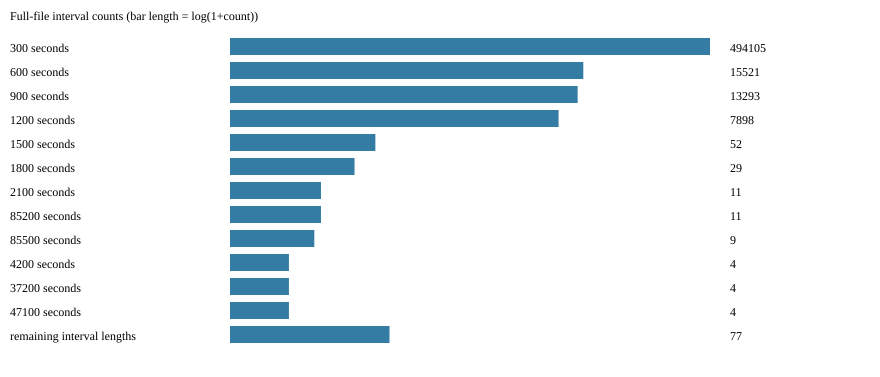

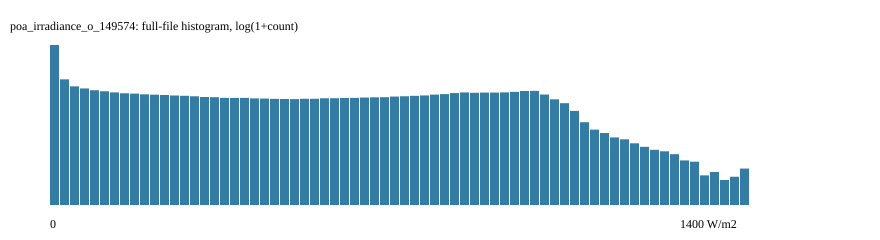

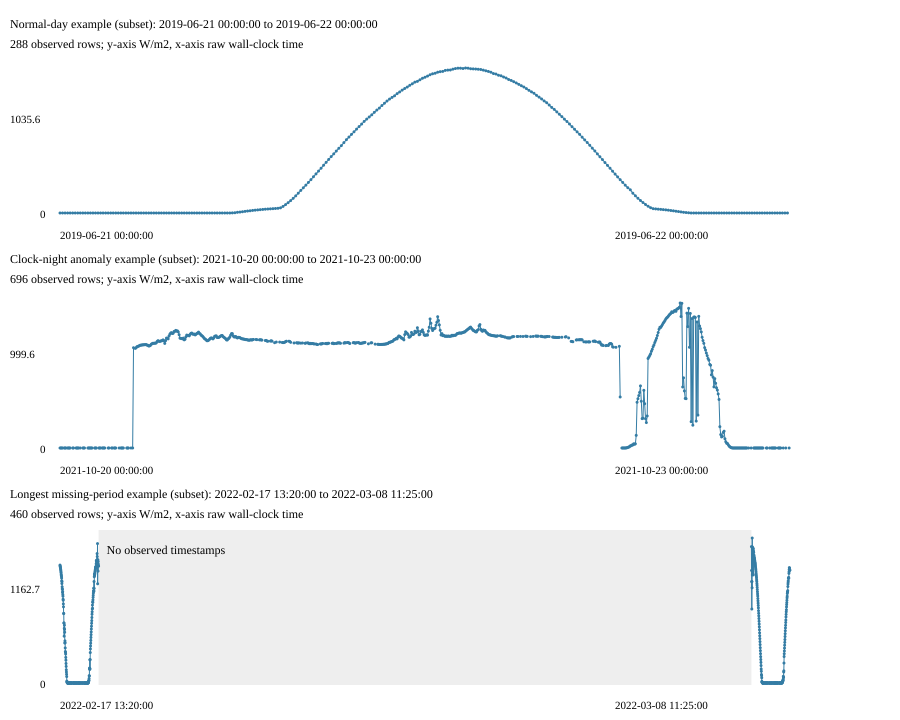

In [7]:
def show_svg(parts,width,height):
    display(SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}"><rect width="100%" height="100%" fill="white"/>'+''.join(parts)+'</svg>'))
frequent=interval_counts['count'].nlargest(12)
items=[(f'{s:g} seconds',int(n)) for s,n in frequent.items()]
items.append(('remaining interval lengths',int(interval_counts['count'].sum()-frequent.sum())))
parts=['<text x="10" y="20">Full-file interval counts (bar length = log(1+count))</text>']
scale=max(np.log1p(n) for _,n in items)
for i,(label,count) in enumerate(items):
    y=38+i*24
    parts.append(f'<text x="10" y="{y+14}" font-size="12">{html.escape(label)}</text><rect x="230" y="{y}" width="{480*np.log1p(count)/scale}" height="17" fill="#347ca4"/><text x="730" y="{y+14}" font-size="12">{count}</text>')
show_svg(parts,880,65+24*len(items))
parts=[]
for k,(channel,values) in enumerate(numeric.items()):
    finite=values[np.isfinite(values)].to_numpy()
    counts,edges=np.histogram(finite,bins=70)
    top=30+k*230
    parts.append(f'<text x="10" y="{top}">{html.escape(channel)}: full-file histogram, log(1+count)</text>')
    scale=max(np.log1p(counts)) or 1
    for j,count in enumerate(counts):
        h=160*np.log1p(count)/scale
        parts.append(f'<rect x="{50+j*10}" y="{top+175-h}" width="9" height="{h}" fill="#347ca4"><title>{edges[j]:g} to {edges[j+1]:g}: {count} rows</title></rect>')
    parts.append(f'<text x="50" y="{top+198}">{edges[0]:g}</text><text x="680" y="{top+198}">{edges[-1]:g} W/m2</text>')
show_svg(parts,880,240*len(CHANNELS))
longest=gap_table.loc[gap_table.seconds.idxmax()]
windows=[('Normal-day example',pd.Timestamp('2019-06-21'),pd.Timestamp('2019-06-22')),
         ('Clock-night anomaly example',pd.Timestamp('2021-10-20'),pd.Timestamp('2021-10-23')),
         ('Longest missing-period example',pd.Timestamp(longest.gap_start)-pd.Timedelta(days=1),pd.Timestamp(longest.gap_end)+pd.Timedelta(days=1))]
parts=[]
for k,(title,start,end) in enumerate(windows):
    top=28+k*235
    mask=(parsed>=start)&(parsed<end)
    parts.append(f'<text x="10" y="{top}">{html.escape(title)} (subset): {start} to {end}</text>')
    parts.append(f'<text x="10" y="{top+20}">{int(mask.sum())} observed rows; y-axis W/m2, x-axis raw wall-clock time</text>')
    if 'missing-period' in title:
        gx=60+730*(pd.Timestamp(longest.gap_start)-start)/(end-start)
        gw=730*(pd.Timestamp(longest.gap_end)-pd.Timestamp(longest.gap_start))/(end-start)
        parts.append(f'<rect x="{gx}" y="{top+32}" width="{gw}" height="155" fill="#eee"/><text x="{gx+8}" y="{top+56}" font-size="12">No observed timestamps</text>')
    for channel,values in numeric.items():
        indices=np.flatnonzero(mask)
        maximum=values[mask].max() or 1
        previous=None
        for i in indices:
            if not np.isfinite(values.iloc[i]):
                previous=None
                continue
            x=60+730*(parsed.iloc[i]-start)/(end-start)
            y=top+185-145*values.iloc[i]/maximum
            if previous is not None and seconds.iloc[i]==300:
                parts.append(f'<line x1="{previous[0]}" y1="{previous[1]}" x2="{x}" y2="{y}" stroke="#347ca4"/>')
            parts.append(f'<circle cx="{x}" cy="{y}" r="1.5" fill="#347ca4"><title>{raw_time.iloc[i]}: {values.iloc[i]:g}</title></circle>')
            previous=(x,y)
        parts.append(f'<text x="10" y="{top+95}" font-size="11">{maximum:g}</text><text x="40" y="{top+190}" font-size="11">0</text>')
    parts.append(f'<text x="60" y="{top+211}" font-size="11">{start}</text><text x="615" y="{top+211}" font-size="11">{end}</text>')
show_svg(parts,900,235*len(windows)+15)

## 7. Integrity and summary evidence
Recheck both input hashes. These tables summarize the full-file audit; no processed files are generated.

In [8]:
for path in (CSV,META):
    assert sha256(path)==input_hashes[str(path.relative_to(ROOT))], 'Input changed during audit'
print('Input SHA-256 checks passed:',input_hashes)
display(pd.Series(coverage))
display(gap_summary)
display(statistics[['column','valid_numeric_count','missing_count','min','max','mean','median','zeros','negatives','positive_0_to_1','above_1000','max_occurrences']])
display(night_summary)
print('Longest bounding missing period:',longest.gap_start,'to',longest.gap_end,longest.gap_duration,
      'candidate absent five-minute slots:',longest.expected_5min_missing)

Input SHA-256 checks passed: {'data\\2107\\raw\\2107_irradiance_data.csv': 'f3820b3c705eecabdc76a9a0363b576cae68bc77492891c5da91017d1489031f', 'data\\2107\\raw\\2107_system_metadata.json': '17e4f7f448fcb2bec43f7610b40c1f7f4fc794ccc185e41dcde0514afba73ae5'}
Longest bounding missing period: 2022-02-18 13:20:00 to 2022-03-07 11:25:00 16 days 22:05:00 candidate absent five-minute slots: 4872


duration                      2191 days 16:45:00
rows                                      531019
naive_5min_slots                          631210
spring_slots_excluded                         72
conditional_expected_slots                631138
naive_absent_slots                        100191
non_dst_absent_slots                      100119
naive_present_pct                      84.127153
conditional_present_pct                 84.13675
dtype: object

,periods,candidate_slots,dst_slots,non_dst_slots
category,,,,
DST only,3,36,36,0
DST plus other missing slots,3,40,36,4
long non-DST,98,33854,0,33854
short non-DST,36809,66261,0,66261


,column,valid_numeric_count,missing_count,min,max,mean,median,zeros,negatives,positive_0_to_1,above_1000,max_occurrences
0,poa_irradiance_o_149574,531019,0,0.0,1400.0,265.144476,34.4,224014,0,855,10006,11


,channel,clock_night_rows,valid,missing,zeros,small_positive_0_to_1,positive_above_1,negative,max
0,poa_irradiance_o_149574,93750,93750,0,93673,0,77,0,768.9


# Irradiance Dataset Audit — Findings Requiring Cleaning Decisions

### A. Observed facts
- One POA channel, `poa_irradiance_o_149574`; metadata identifies metric 149574, sensor `poa_irradiance`, W/m?, averaging, scale 1 and offset 0. CSV/metric names, IDs, and units agree; system-level coverage dates differ.
- 531,019 rows from `2017-11-01 07:10:00` to `2023-11-01 23:55:00`. Unique, strictly increasing timestamps; no parse failures or duplicate rows.
- Five minutes accounts for 494,105 of 531,018 intervals (93.05%). There are 68 interval lengths; 10-, 15-, and 20-minute steps are frequent and concentrated overnight. Absent timestamps are not measurement NaNs.
- Coverage benchmark: 2191 days 16:45 of naive wall-clock time; 631,210 five-minute slots. Excluding 72 spring-DST slots leaves 631,138 expected slots: 531,019 present (84.13675%) and 100,119 absent. This conditional benchmark does not resolve fall ambiguity or assert data-loss causes.
- Gaps: 36,809 short non-DST periods (bounding interval <=1 hour), 98 long periods (>1 hour), and six DST-overlap periods. Three DST overlaps also contain four non-DST absent slots in total. The longest gap is `2022-02-18 13:20:00` to `2022-03-07 11:25:00`: 16 days 22:05, with 4,872 candidate absent samples.
- Spring 02:xx is absent on all six covered Pacific transitions; fall 01:xx strings do not repeat. Evidence matches the electrical dataset's wall-clock pattern and unresolved fall handling; irradiance coverage starts later and ends earlier.
- Measurements are finite, 0?1400 W/m?, with no missing/negative/nonnumeric values. There are 224,014 zeros, 855 positive values <=1, 10,006 values above 1000, and 11 readings exactly 1400.
- The clock-night subset has 93,750 rows: 93,673 zeros and 77 positive readings, all on October 21?22, 2021, reaching 768.9 W/m2. No clock-night missing, negative, or (0,1] values. Selected neighborhoods show these unusual overnight measurements.

### B. Tentative interpretations
- Pacific DST-aware wall-clock timestamps are supported; the retained fall-hour occurrence and export convention remain unknown.
- Frequent longer overnight intervals may be a reporting convention. They cannot all be called accidental data loss. Five-minute alignment is not yet reliable without a policy for absent slots.
- Values above 1000 can be plausible high POA. Repeated 1400 maxima suggest a possible sensor/export ceiling; local contrasts need context. No orders-of-magnitude numeric corruption is established by the observed range.
- Positive clock-night readings suggest sensor/export or timestamp issues conditional on the Pacific interpretation. The night proxy is not an astronomical classification.
- Multi-day gaps make broad interpolation unsafe without further evidence. After QC and coverage/timezone decisions, measured POA appears a candidate for direct use; model suitability is still undecided.

### C. Decisions still required
- Confirm sensor ceiling/calibration, the positive-night episode, and selected high/local-contrast readings before flagging or replacing values.
- Confirm overnight reporting cadence, wall-clock/fall conventions, and later cross-dataset alignment.
- Decide how to represent absent timestamps and long outages. The audit implements no filling, resampling, interpolation, or modelling decisions. Approved flag-only processing follows.

## A. Approved cleaning rules
- Preserve all 531,019 rows, raw timestamp strings, numerical values, zeros, and gaps. No filling, UTC conversion, interpolation, resampling, clipping, or replacements.
- Flag 11 exact 1400 readings and 77 audited positive clock-night readings without changing them.
- Flag the three existing `large local contrast` audit candidates. No new threshold or spike definition.
- Raw hash must match the reviewed audit. All flagged values remain unresolved.

In [9]:
import pyarrow as pa
import pyarrow.parquet as pq
AUDIT_SHA256 = 'f3820b3c705eecabdc76a9a0363b576cae68bc77492891c5da91017d1489031f'
EXPECTED_ROWS = 531019
POA = 'poa_irradiance_o_149574'
assert header == [TIMESTAMP,POA] and len(frame)==EXPECTED_ROWS
assert sha256(CSV)==AUDIT_SHA256, 'Raw CSV differs from the reviewed audit'
assert statistics.missing_count.sum()==0 and statistics.nonnumeric_count.sum()==0
print('Approved audited input confirmed; pyarrow',pa.__version__)

Approved audited input confirmed; pyarrow 25.0.1


## B. QC-event generation
Reuse the audit masks and exact spike list. The five-field ledger records observations only; no values are changed. `measurement` is the original POA column name.

In [10]:
spikes=suspicious.loc[suspicious.review_label=='large local contrast']
approved_spikes=[
    (127858,'2019-04-16 11:50:00',1250.7),
    (317257,'2021-04-25 12:40:00',1390.6),
    (481133,'2023-04-11 13:40:00',1223.2),
]
assert list(spikes[['row','timestamp','value']].itertuples(index=False,name=None))==approved_spikes
flag_rows={
    'qc_suspect_ceiling':np.flatnonzero(numeric[POA].eq(1400)),
    'qc_suspect_night':np.flatnonzero(night & numeric[POA].gt(0)),
    'qc_suspect_spike':spikes.row.to_numpy(dtype=int),
}
expected_counts={'qc_suspect_ceiling':11,'qc_suspect_night':77,'qc_suspect_spike':3}
assert {flag:len(rows) for flag,rows in flag_rows.items()}==expected_counts
assert set(parsed.iloc[flag_rows['qc_suspect_night']].dt.strftime('%Y-%m-%d'))=={'2021-10-21','2021-10-22'}
reasons={
    'qc_suspect_ceiling':'Repeated exact high value; review required',
    'qc_suspect_night':'Positive clock-night value; timestamp/sensor review',
    'qc_suspect_spike':'Audited local contrast; validity unresolved',
}
QC_COLUMNS=[TIMESTAMP,'measurement','raw_value','flag','reason']
qc_records=[dict(zip(QC_COLUMNS,(raw_time.iloc[row],POA,float(frame[POA].iloc[row]),flag,reasons[flag])))
            for flag,rows in flag_rows.items() for row in rows]
qc_events=pd.DataFrame(qc_records,columns=QC_COLUMNS).sort_values([TIMESTAMP,'flag'],kind='stable').reset_index(drop=True)
assert not qc_events.duplicated([TIMESTAMP,'measurement','flag']).any()
display(qc_events.groupby('flag').size().rename('events').to_frame())
print('QC records:',len(qc_events),'? no corrupt/replacement flags')

QC records: 91 ? no corrupt/replacement flags


,events
flag,
qc_suspect_ceiling,11
qc_suspect_night,77
qc_suspect_spike,3


## C. Parquet generation
The narrow two-column file fits in memory. Parse original numeric tokens as float64 with Python's round-trip precision; do not reuse rounded audit statistics. Reruns replace only these two derived files.

In [11]:
assert sha256(CSV)==AUDIT_SHA256
raw_values=np.fromiter((float(token) for token in frame[POA]),dtype=np.float64,count=EXPECTED_ROWS)
clean_frame=pd.DataFrame({TIMESTAMP:raw_time.to_numpy(copy=True),POA:raw_values})
assert clean_frame[POA].notna().all()
clean_schema=pa.schema([(TIMESTAMP,pa.string()),(POA,pa.float64())])
qc_schema=pa.schema([(TIMESTAMP,pa.string()),('measurement',pa.string()),
                     ('raw_value',pa.float64()),('flag',pa.string()),('reason',pa.string())])
PROCESSED=ROOT / 'data/2107/processed'
CLEAN_PATH=PROCESSED / '2107_irradiance_clean.parquet'
QC_PATH=PROCESSED / '2107_irradiance_qc_events.parquet'
PROCESSED.mkdir(parents=True,exist_ok=True)
pq.write_table(pa.Table.from_pandas(clean_frame,schema=clean_schema,preserve_index=False),
               CLEAN_PATH,compression='snappy',row_group_size=50000)
pq.write_table(pa.Table.from_pandas(qc_events,schema=qc_schema,preserve_index=False),
               QC_PATH,compression='snappy')
print('Written:',CLEAN_PATH.relative_to(ROOT),QC_PATH.relative_to(ROOT))

Written: data\2107\processed\2107_irradiance_clean.parquet data\2107\processed\2107_irradiance_qc_events.parquet


## D. Validation
Read Parquet back and independently reread only the irradiance CSV with round-trip numeric parsing. Compare every timestamp and value, validate each QC reference, and recheck both raw input hashes. Equality preserves row order, gaps, DST strings, zeros, and all flagged observations.

In [12]:
raw_check=pd.read_csv(CSV,dtype={POA:np.float64},converters={TIMESTAMP:str},float_precision='round_trip')
clean_table=pq.read_table(CLEAN_PATH)
assert clean_table.schema.equals(clean_schema,check_metadata=False)
roundtrip=clean_table.to_pandas()
assert len(roundtrip)==len(raw_check)==EXPECTED_ROWS
assert list(roundtrip.columns)==list(raw_check.columns)==header
assert np.array_equal(roundtrip[TIMESTAMP].to_numpy(),raw_check[TIMESTAMP].to_numpy())
assert np.array_equal(raw_check[TIMESTAMP].to_numpy(),raw_time.to_numpy())
assert np.array_equal(roundtrip[POA].to_numpy(),raw_check[POA].to_numpy())
assert np.array_equal(roundtrip[POA].to_numpy(),raw_values)
assert roundtrip[POA].notna().all()
assert np.array_equal(roundtrip[POA].eq(0).to_numpy(),raw_check[POA].eq(0).to_numpy())
qc_table=pq.read_table(QC_PATH)
assert qc_table.schema.equals(qc_schema,check_metadata=False)
qc_roundtrip=qc_table.to_pandas()
assert list(qc_roundtrip.columns)==QC_COLUMNS
pd.testing.assert_frame_equal(qc_roundtrip,qc_events,check_dtype=False,check_exact=True)
assert qc_roundtrip.groupby('flag').size().to_dict()==expected_counts
for flag,rows in flag_rows.items():
    events=qc_roundtrip.loc[qc_roundtrip.flag==flag]
    expected_timestamps=raw_check.iloc[rows][TIMESTAMP].to_numpy()
    assert np.array_equal(events[TIMESTAMP].to_numpy(),expected_timestamps)
    assert events.measurement.eq(POA).all() and events.reason.eq(reasons[flag]).all()
    assert np.array_equal(events.raw_value.to_numpy(),raw_check.iloc[rows][POA].to_numpy())
    assert np.array_equal(roundtrip.iloc[rows][POA].to_numpy(),raw_check.iloc[rows][POA].to_numpy())
assert roundtrip[POA].eq(1400).sum()==11
for path in (CSV,META):
    assert sha256(path)==input_hashes[str(path.relative_to(ROOT))]
assert sha256(CSV)==AUDIT_SHA256
validation_report=dict(rows=len(roundtrip),changed_poa_values=0,
    timestamps_and_order_preserved=True,no_added_timestamps_or_filled_gaps=True,
    zeros_preserved=int(roundtrip[POA].eq(0).sum()),all_flagged_values_preserved=True,
    qc_events=len(qc_roundtrip),**expected_counts,parquet_types_verified=True,
    raw_sha256=AUDIT_SHA256)
display(pd.Series(validation_report,name='validation'))
print('Validation passed. No raw measurements or timestamps changed.')

Validation passed. No raw measurements or timestamps changed.


rows                                                                             531019
changed_poa_values                                                                    0
timestamps_and_order_preserved                                                     True
no_added_timestamps_or_filled_gaps                                                 True
zeros_preserved                                                                  224014
all_flagged_values_preserved                                                       True
qc_events                                                                            91
qc_suspect_ceiling                                                                   11
qc_suspect_night                                                                     77
qc_suspect_spike                                                                      3
parquet_types_verified                                                             True
raw_sha256                      